In [199]:
import pandas as pd
import os
from datetime import datetime

# ML libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

### Data Ingest

In [93]:
# Load the NCAA advanced player stats dataset
f_ncaa = '../data/2008_2025_ncaa_advanced_player_stats.csv'
df_ncaa = pd.read_csv(f_ncaa, index_col=0, dtype=object)
year_min = int(df_ncaa['year'].min())
df_ncaa.reset_index(inplace=True)
df_ncaa.head()

,player_name,team,conf,GP,Min_per,ORtg,usg,eFG,TS_per,ORB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,role,3p/100?
0,Jason Praet,Detroit Mercy,Horz,6,1.0,0.0,16.8,0.0,0.0,0.0,...,-1.49938,0.1429,0.1429,0.2857,0.0,0.2857,0.0,0.0,NaN,5.70546
1,DeAndrae Ross,South Alabama,SB,22,8.4,62.0,14.1,32.6,33.4,0.0,...,-1.91216,0.0,0.3333,0.3333,0.2083,0.0833,0.0,0.75,NaN,6.20657
2,Pooh Williams,Utah St.,WAC,28,24.3,93.1,13.8,45.2,46.2,1.4,...,-0.713339,0.1379,0.6897,0.8276,1.0,0.3793,0.069,2.4483,NaN,4.26818
3,Mohamed Tangara,Arizona,P10,6,1.0,15.8,18.4,0.0,0.0,9.7,...,-1.82501,0.1667,0.0,0.1667,0.0,0.0,0.1667,0.0,NaN,4.60267
4,Jesus Verdejo,South Florida,BE,30,71.1,105.8,19.0,50.6,54.16,2.3,...,-0.478177,0.6,2.2333,2.8333,2.6333,0.5667,0.0667,10.7,NaN,7.81267


In [ ]:
# Load the draft history dataset - subsetting to seasons available in NCAA dataset
f_draft = '../data/alltime_draft_20250718.csv'
df_draft = pd.read_csv(f_draft, index_col=0, dtype=object)
df_draft['SEASON'] = df_draft['SEASON'].astype(int)
df_draft = df_draft[df_draft['SEASON'] >= year_min]
df_draft.head()

,PERSON_ID,PLAYER_NAME,SEASON,ROUND_NUMBER,ROUND_PICK,OVERALL_PICK,DRAFT_TYPE,TEAM_ID,TEAM_CITY,TEAM_NAME,TEAM_ABBREVIATION,ORGANIZATION,ORGANIZATION_TYPE,PLAYER_PROFILE_FLAG
0,1642258,Zaccharie Risacher,2024,1,1,1,Draft,1610612737,Atlanta,Hawks,ATL,JL Bourg (France),Other Team/Club,1
1,1642259,Alex Sarr,2024,1,2,2,Draft,1610612764,Washington,Wizards,WAS,Perth Wildcats (Australia),Other Team/Club,1
2,1642263,Reed Sheppard,2024,1,3,3,Draft,1610612745,Houston,Rockets,HOU,Kentucky,College/University,1
3,1642264,Stephon Castle,2024,1,4,4,Draft,1610612759,San Antonio,Spurs,SAS,Connecticut,College/University,1
4,1641842,Ronald Holland II,2024,1,5,5,Draft,1610612765,Detroit,Pistons,DET,Ignite (G League),Other Team/Club,1


In [148]:
# Load the NBA stats dataset - subsetting to seasons available in NCAA dataset
dir_nba = '../data/player_season_stats'
tmp_df_list = []
for file in os.listdir(dir_nba):
    if file.endswith('.csv'):
        f_nba = os.path.join(dir_nba, file)
        tmp_df = pd.read_csv(f_nba, index_col=0, dtype=object)
        # print(f"Loaded {file} with shape {tmp_df.shape}")
        tmp_df_list.append(tmp_df)
df_nba = pd.concat(tmp_df_list, ignore_index=True)
del tmp_df_list
df_nba['season_year_start'] = df_nba['season_year_start'].astype(int)
df_nba = df_nba[df_nba['season_year_start'] >= year_min]
df_nba.head()

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,season_id,season_year_start
5341,201166,Aaron Brooks,Aaron,1610612745,HOU,24.0,80,52,28,0.65,...,162,136,79,183,141,15,169,1,2008-09,2008
5342,201189,Aaron Gray,Aaron,1610612741,CHI,24.0,56,26,30,0.464,...,298,335,259,286,174,15,297,1,2008-09,2008
5343,201151,Acie Law,Acie,1610612737,ATL,24.0,55,33,22,0.6,...,292,366,195,377,229,15,384,1,2008-09,2008
5344,200747,Adam Morrison,Adam,1610612747,LAL,24.0,52,23,29,0.442,...,389,314,337,367,229,15,345,2,2008-09,2008
5345,1502,Adonal Foyle,Adonal,1610612753,ORL,34.0,10,6,4,0.6,...,428,417,265,370,229,15,386,2,2008-09,2008


In [ ]:
# Load the NBA all star dataset - subsetting to seasons available in NCAA dataset
f_all_star = '../data/nba_allstar_all_20250528.csv'
df_all_star = pd.read_csv(f_all_star, index_col=0, dtype=object)
df_all_star['Year'] = df_all_star['Year'].astype(int)
df_all_star = df_all_star[df_all_star['Year'] + 1 >= year_min] # Add 1 to account for the all-star game being in the next year
df_all_star.head()

,Player,Pos,HT,WT,Team,Selection Type,NBA Draft Status,Nationality,Year
1343,Ray Allen,SG,6-5,205,Seattle SuperSonics,Western All-Star Replacement Selection,1996 Rnd 1 Pick 5,United States,2007
1344,Carmelo Anthony,F,6-8,240,Denver Nuggets,Western All-Star Replacement Selection,2003 Rnd 1 Pick 3,United States,2007
1345,Carlos Boozer,PF,6-9,266,Utah Jazz,Western All-Star Coaches Selection,2002 Rnd 2 Pick 6,Germany United States,2007
1346,Kobe Bryant,SG,6-6,212,Los Angeles Lakers,Western All-Star Fan Vote Selection,1996 Rnd 1 Pick 13,United States,2007
1347,Tim Duncan,FC,6-11,250,San Antonio Spurs,Western All-Star Fan Vote Selection,1997 Rnd 1 Pick 1,United States,2007


In [47]:
# Load the all-nba dataset
f_allnba = '../data/allnba_players.csv'
df_allnba = pd.read_csv(f_allnba, dtype=object)
df_allnba['year'] = df_allnba['SEASON'].apply(lambda x: int(x.split('-')[0]) + 1)
df_allnba = df_allnba[df_allnba['year'] + 1 >= year_min]
df_allnba.head()

,PLAYER,TEAM,SEASON,NTEAM,year
0,Giannis Antetokounmpo,Milwaukee Bucks,2024-25,1,2025
1,Shai Gilgeous-Alexander,Oklahoma City Thunder,2024-25,1,2025
2,Nikola Jokić,Denver Nuggets,2024-25,1,2025
3,Donovan Mitchell,Cleveland Cavaliers,2024-25,1,2025
4,Jayson Tatum,Boston Celtics,2024-25,1,2025


### Create player category data - The Y values

In [48]:
# Create a cleaned set of all-star names
all_star_names = set(df_all_star['Player'].str.strip().str.lower())

# Tag draft players if their cleaned name is in the all-star set
df_draft['all_star'] = df_draft['PLAYER_NAME'].apply(
    lambda x: 1 if x.strip().lower() in all_star_names else 0
)

# Tag draft players if they are in the all-nba dataset
all_nba_names = set(df_allnba['PLAYER'].str.strip().str.lower())
df_draft['all_nba'] = df_draft['PLAYER_NAME'].apply(
    lambda x: 1 if x.strip().lower() in all_nba_names else 0
)

#### Slightly more complicated - need to also categorize as starter, bench, or out of the league

In [149]:
# Determine if a player is a starter based on their minutes played
# We will use a rolling mean for minutes played over 3 seasons to determine this
df_nba = df_nba.sort_values(by=['PLAYER_NAME', 'season_year_start'])

# Compute 3-year rolling average of MIN, grouped by player
df_nba['rolling_min3'] = (
    df_nba.groupby('PLAYER_NAME')['MIN']
    .rolling(window=3, min_periods=3)
    .mean()
    .reset_index(level=0, drop=True)
)

# Flag players who ever exceed 20 in rolling avg
starter_players = (
    df_nba[df_nba['rolling_min3'] > 20]['PLAYER_NAME']
    .unique()
)

df_draft['starter'] = df_draft['PLAYER_NAME'].apply(
    lambda x: 1 if x.strip().lower() in [name.lower() for name in starter_players] else 0
)

In [150]:
# Determine if a player is a starter based on their minutes played
# We will use a rolling mean for minutes played over 5 seasons to determine this
# 5 seasons is selected because it can take several years to find out of a player is at least a bench player or not
df_nba = df_nba.sort_values(by=['PLAYER_NAME', 'season_year_start'])

# Compute 3-year rolling average of MIN, grouped by player
df_nba['rolling_min5'] = (
    df_nba.groupby('PLAYER_NAME')['MIN']
    .rolling(window=5, min_periods=5)
    .mean()
    .reset_index(level=0, drop=True)
)

# Flag players who ever exceed 20 in rolling avg
bench_players = (
    df_nba[df_nba['rolling_min5'] > 10]['PLAYER_NAME']
    .unique()
)

df_draft['bench'] = df_draft['PLAYER_NAME'].apply(
    lambda x: 1 if x.strip().lower() in [name.lower() for name in bench_players] else 0
)

#### Adding our y values to the NCAA stats

In [231]:
# add allstar, starter, bench, and all_nba to the NCAA dataset
df_main = df_ncaa.merge(
    df_draft[['PLAYER_NAME', 'all_star', 'starter', 'bench', 'all_nba']],
    left_on='player_name',
    right_on='PLAYER_NAME',
    how='left'
)

# subset to the most recent season for each player
df_main = df_main.sort_values('year', ascending=False)\
    .drop_duplicates(subset='PLAYER_NAME', keep='first')

In [221]:
# add allstar, starter, bench, and all_nba to the NCAA dataset
df_main = df_ncaa.merge(
    df_draft[['PLAYER_NAME', 'all_star', 'starter', 'bench', 'all_nba']],
    left_on='player_name',
    right_on='PLAYER_NAME',
    how='left'
)

# subset to the most recent season for each player
df_main = df_main.sort_values('year', ascending=False)\
    .drop_duplicates(subset='PLAYER_NAME', keep='first')

# create outcome category based on all_star, starter, bench, and all_nba
# ordering by priority: all_nba > all_star > starter > bench
def categorize_player(row):
    if row['all_nba'] == 1:
        return 'All-NBA'
    elif row['all_star'] == 1:
        return 'All-Star'
    elif row['starter'] == 1:
        return 'Starter'
    elif row['bench'] == 1:
        return 'Bench'
    else:
        return 'Out of League'
    
df_main['category'] = df_main.apply(categorize_player, axis=1)

# Convert year to integer for easier calculations
year_now = datetime.now().year
df_main['year'] = df_main['year'].astype(int)

# preserve the most recent year for predictions
df_now = df_main[df_main['year'] == year_now]

# lastly, we care about retaining players who are allstars/all-nba early in their career
# but will otherwise not include players who have had fewer than 3 seasons in the league
# also consider that the year value represents the final year of the player's ncaa career before being drafted
drop_logic = (year_now - df_main['year']) < 3
drop_logic = drop_logic & (~df_main['category'].isin(['All-NBA', 'All-Star']))
df_main = df_main[~drop_logic]

### Data Investigation

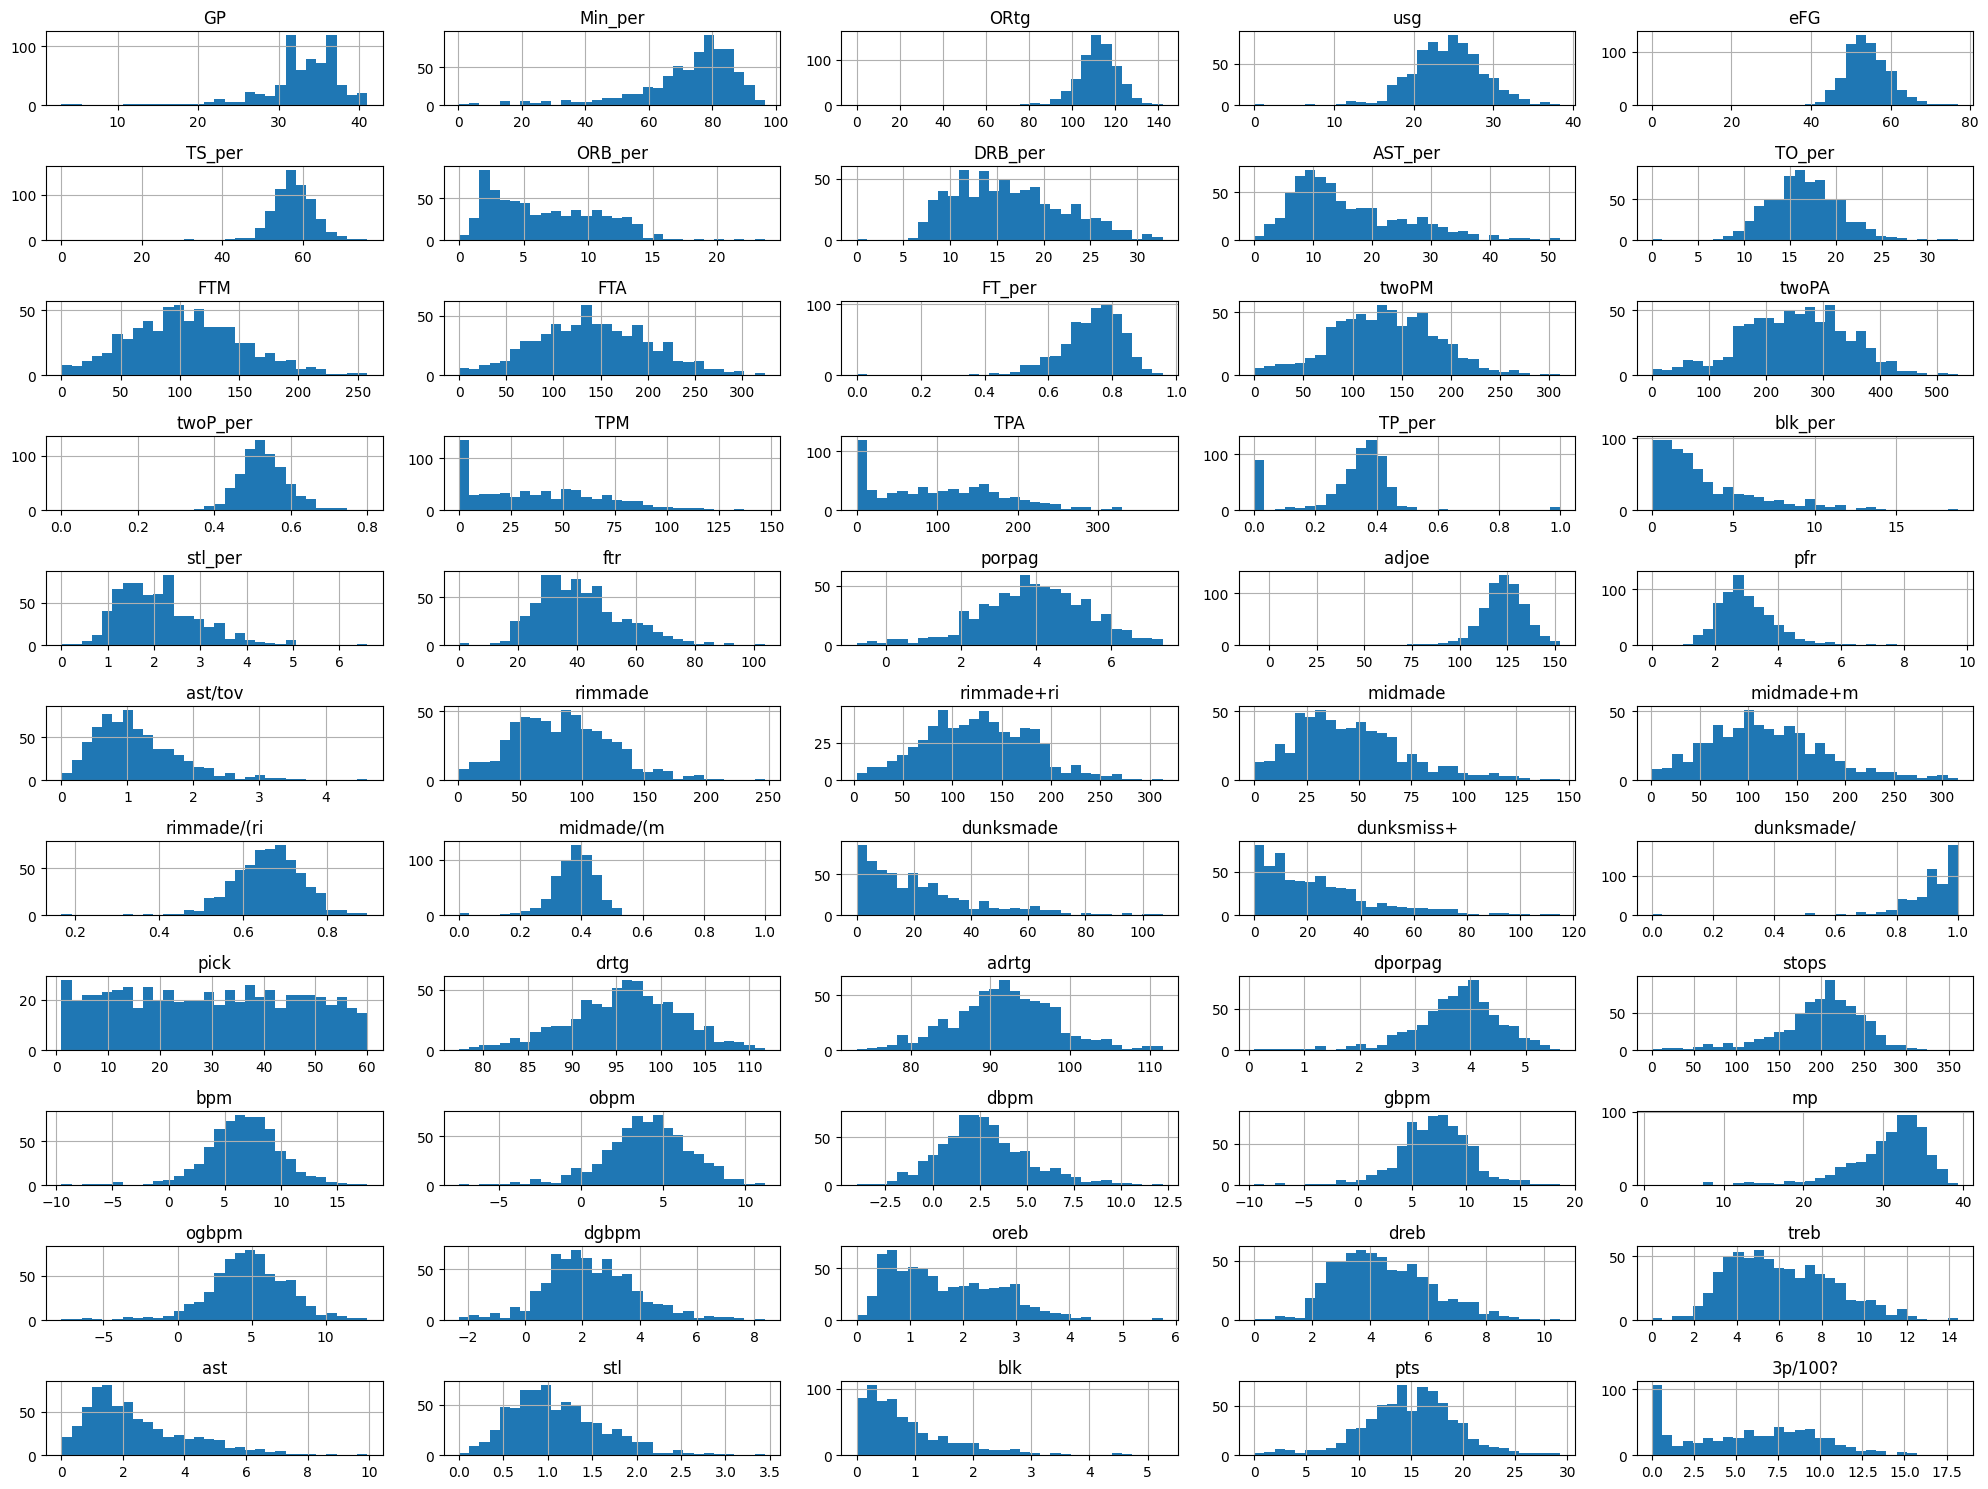

In [155]:
# Select relevant numeric columns for ML investigation (excluding identifiers and target columns)
exclude_cols = [
    'player_name', 'team', 'conf', 'yr', 'ht', 'num', 'year', 'pid', 'type', 'Rec Rank', 'role', 'PLAYER_NAME',
    'all_star', 'starter', 'bench', 'all_nba'
]
# Get numeric columns only (try to convert to float, ignore errors)
numeric_cols = []
for col in df_main.columns:
    if col not in exclude_cols:
        try:
            df_ncaa[col].astype(float)
            numeric_cols.append(col)
        except Exception:
            continue

# Plot histograms for each relevant numeric column
df_main[numeric_cols].astype(float).hist(bins=30, figsize=(20, 15), layout=(-1, 5))
plt.tight_layout()
plt.show()

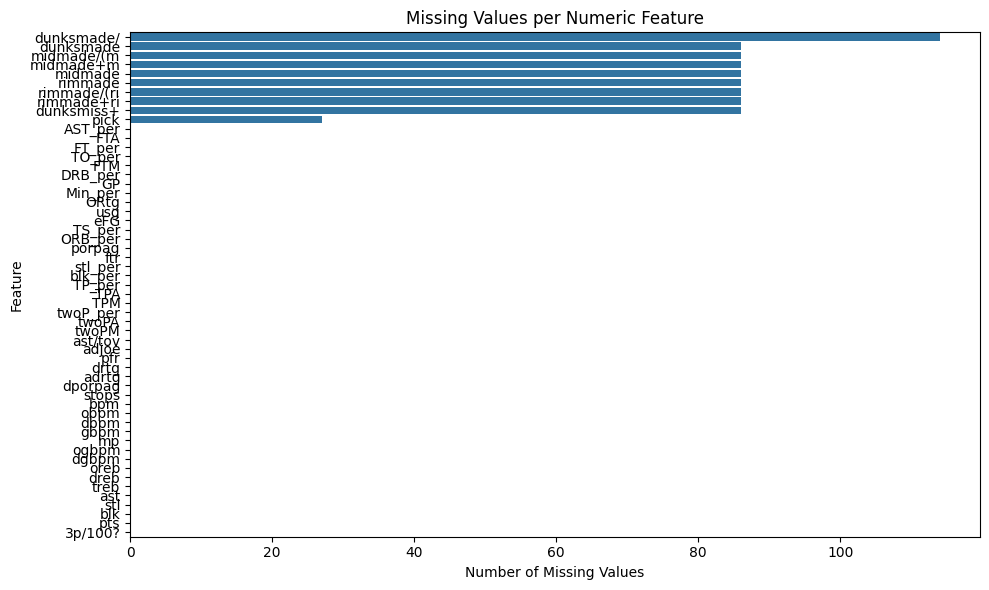

In [170]:
# Plot the number of missing values for each numeric column
na_counts = df_main[numeric_cols].isna().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=na_counts.values, y=na_counts.index, orient='h')
plt.xlabel('Number of Missing Values')
plt.ylabel('Feature')
plt.title('Missing Values per Numeric Feature')
plt.tight_layout()
plt.show()


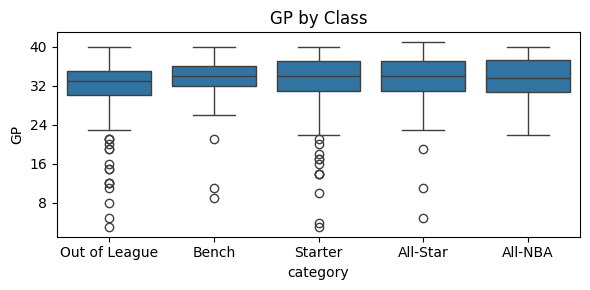

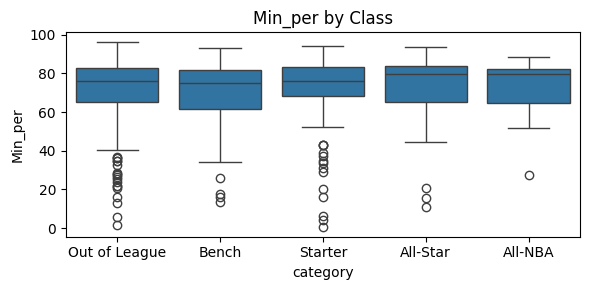

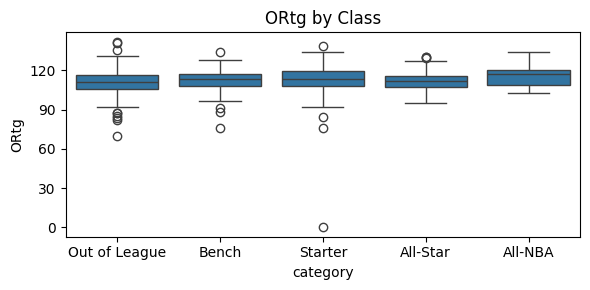

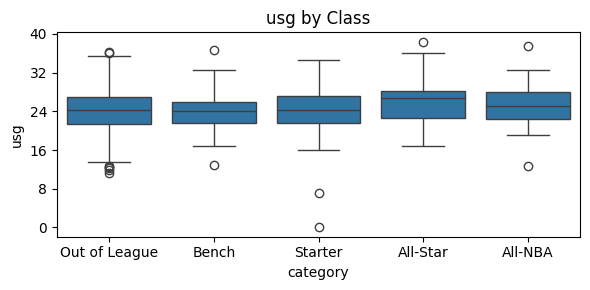

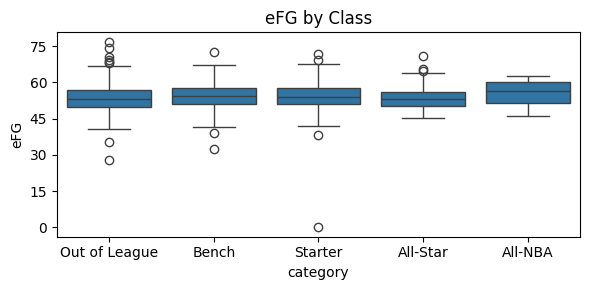

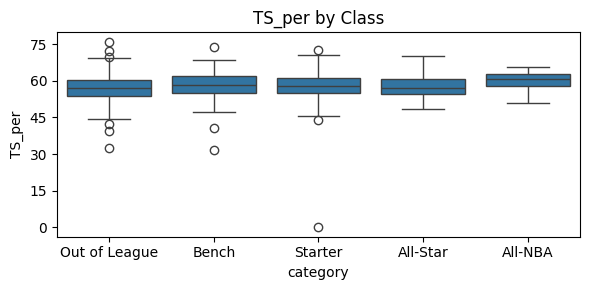

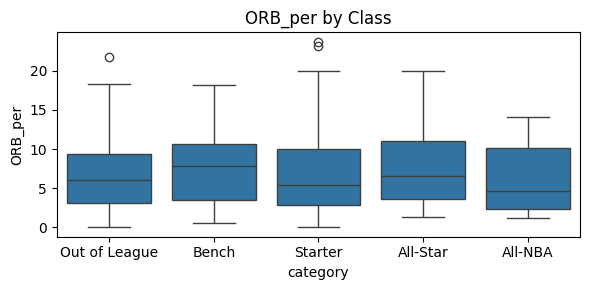

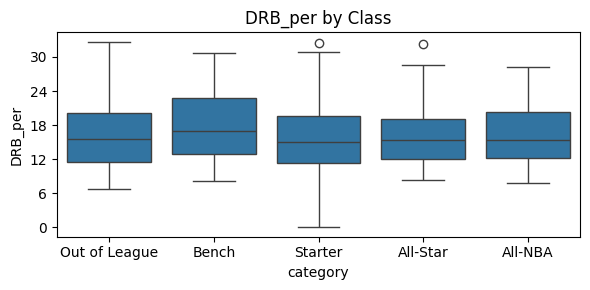

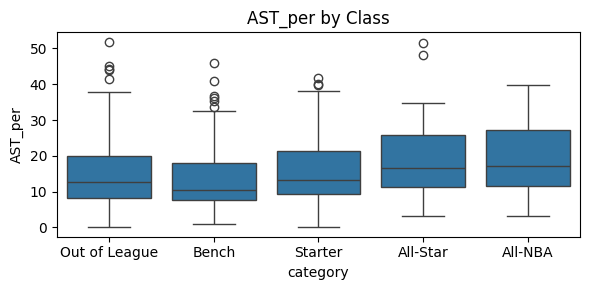

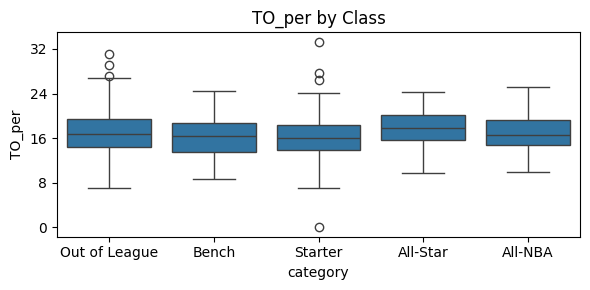

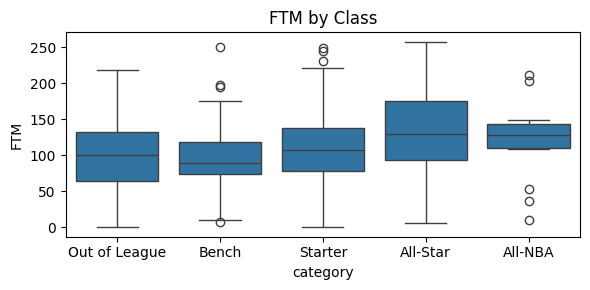

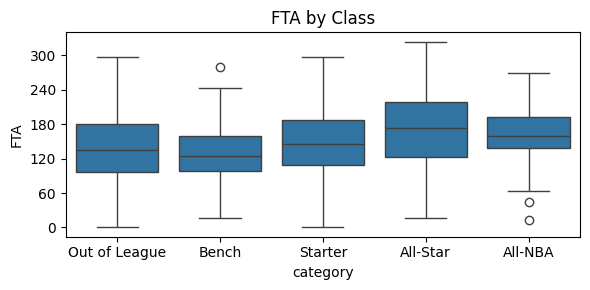

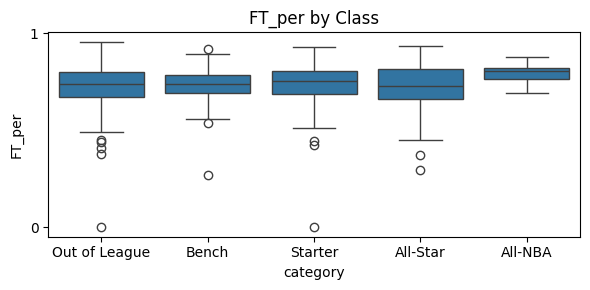

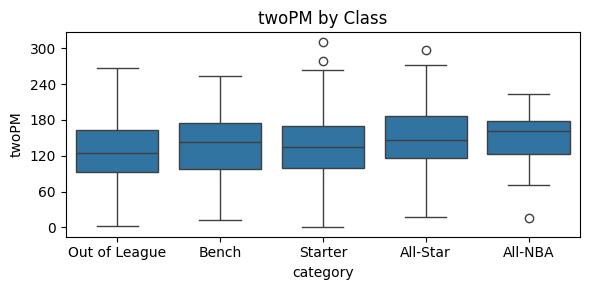

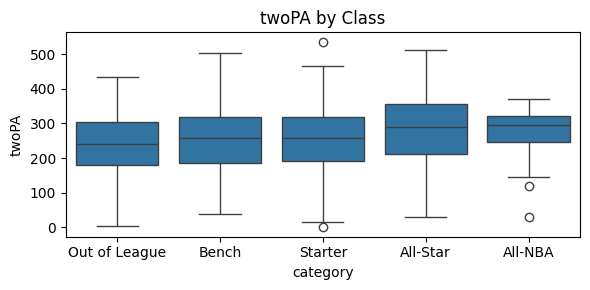

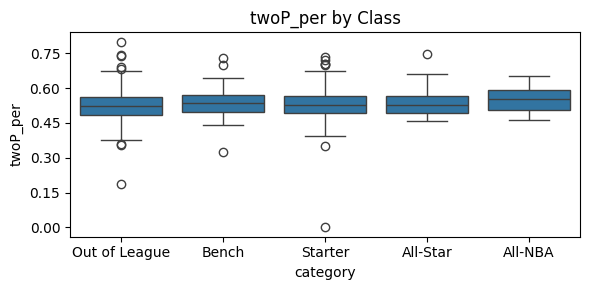

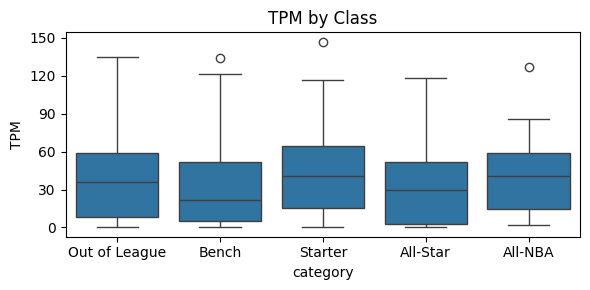

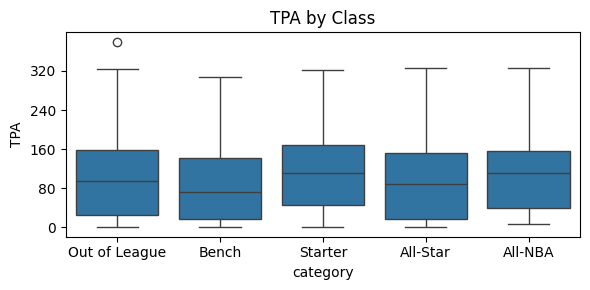

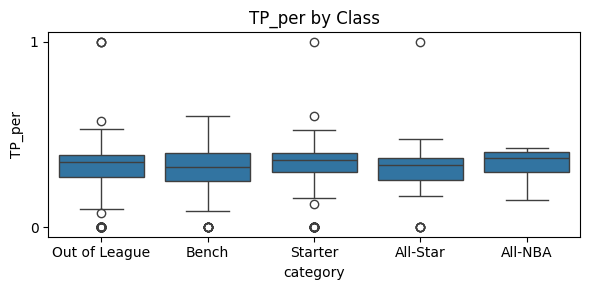

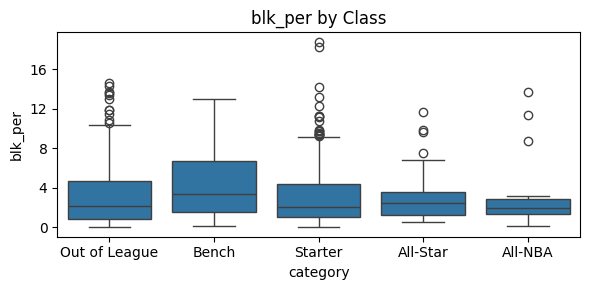

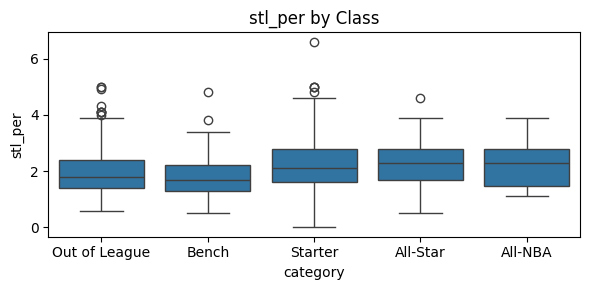

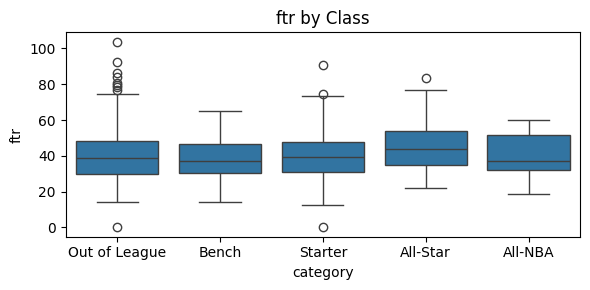

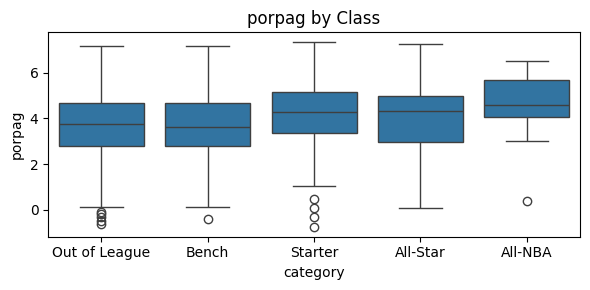

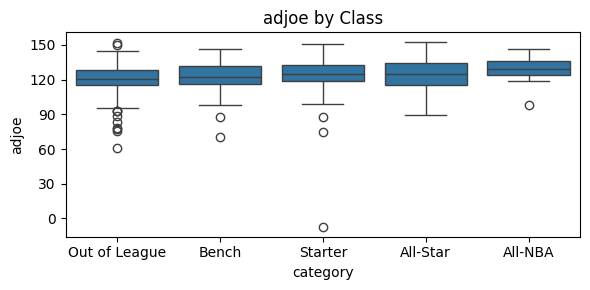

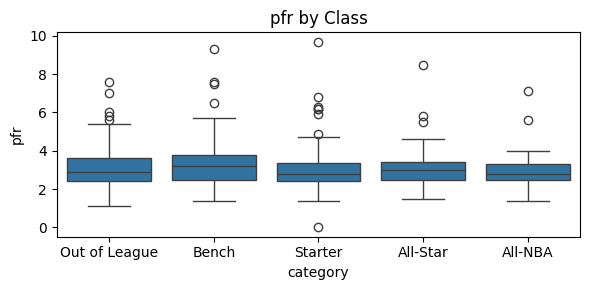

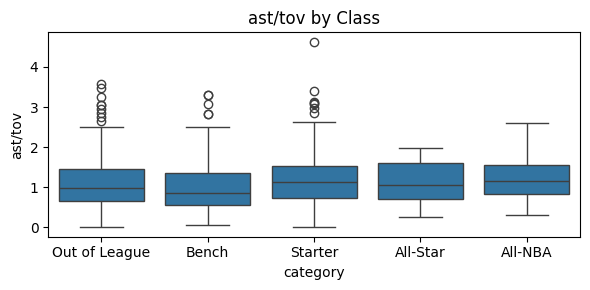

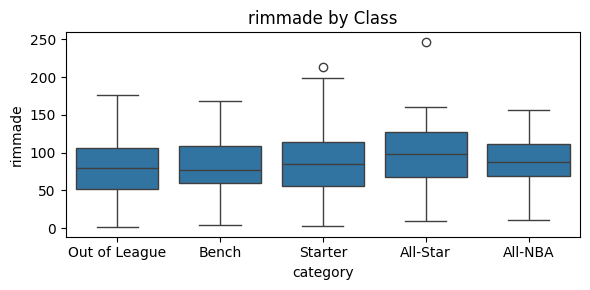

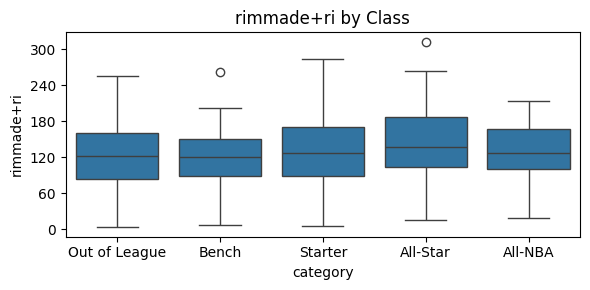

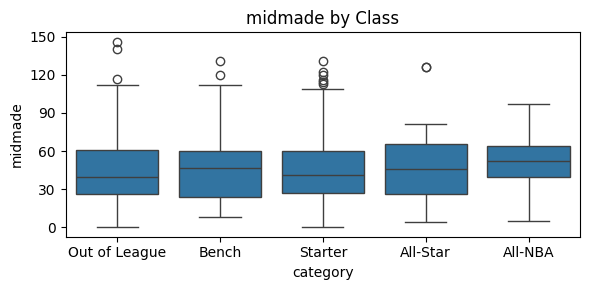

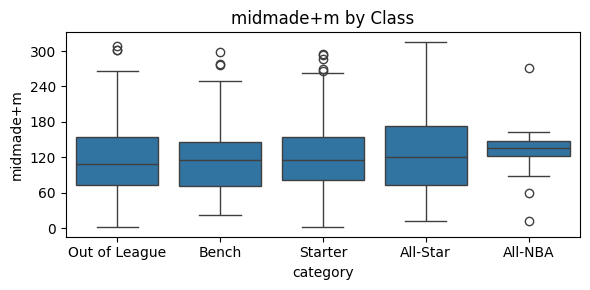

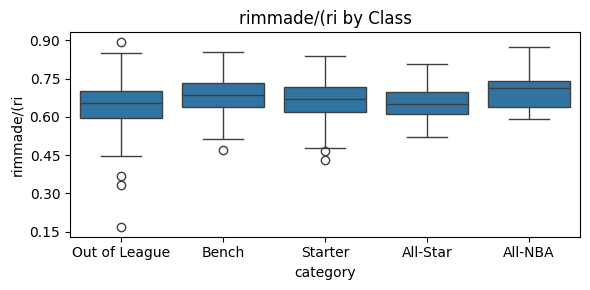

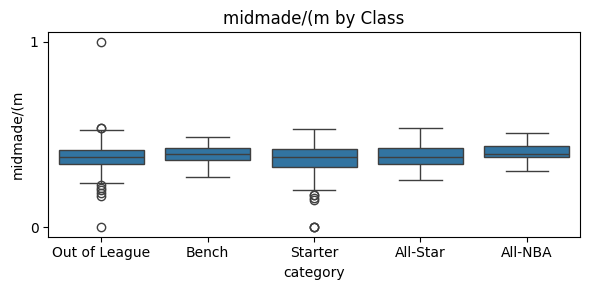

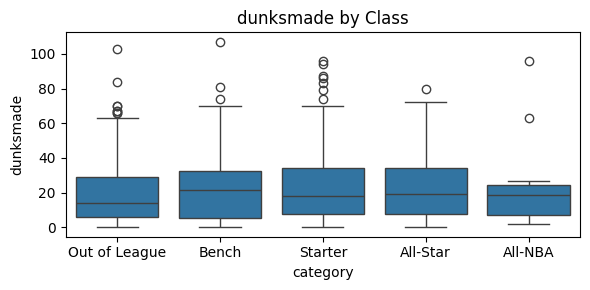

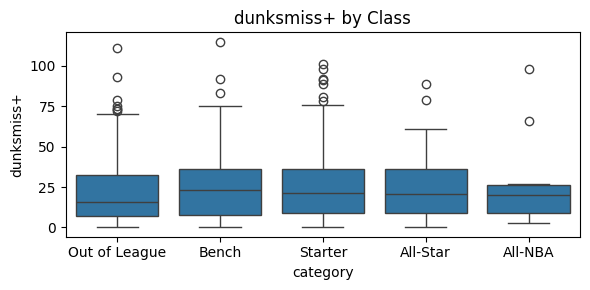

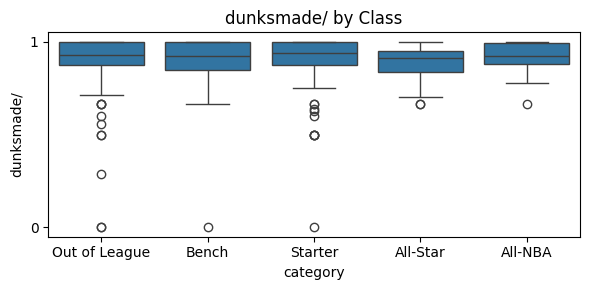

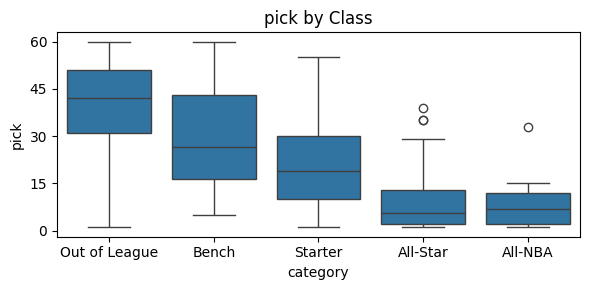

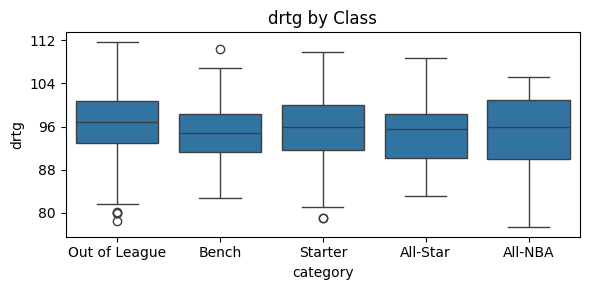

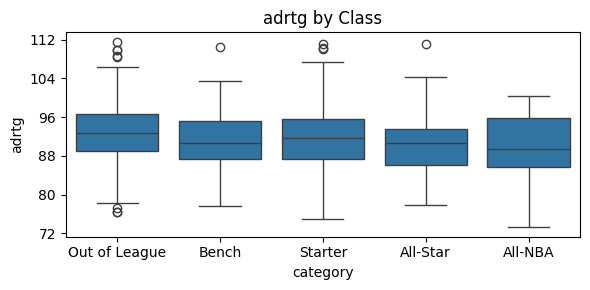

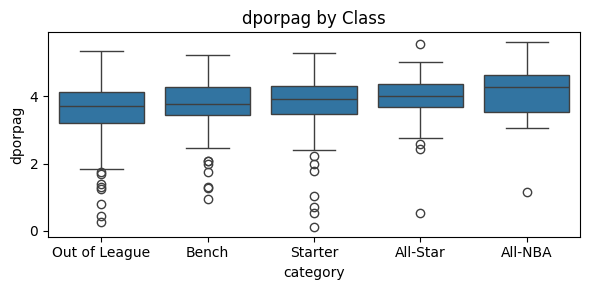

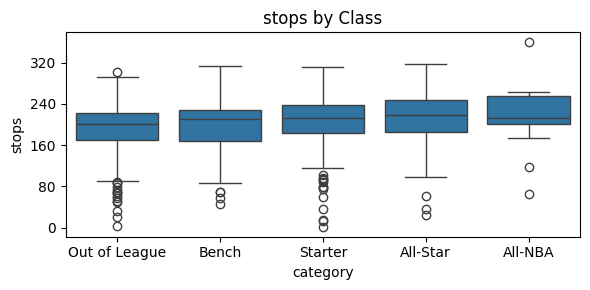

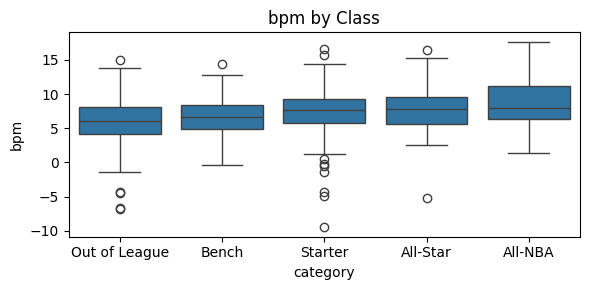

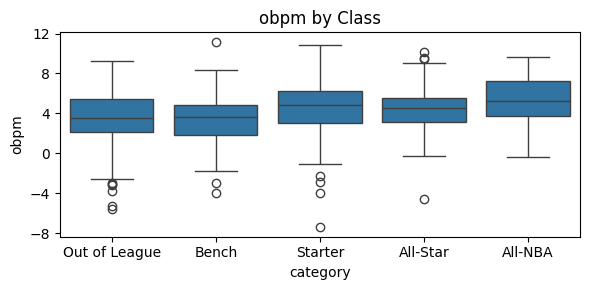

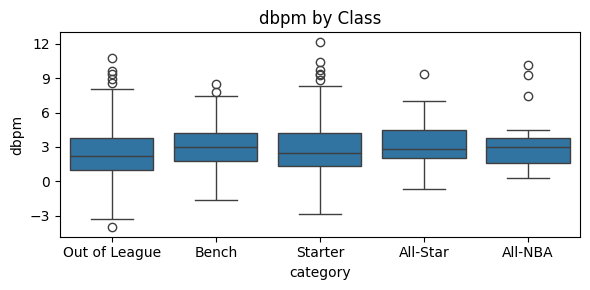

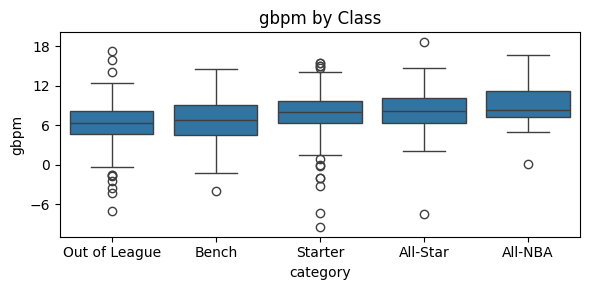

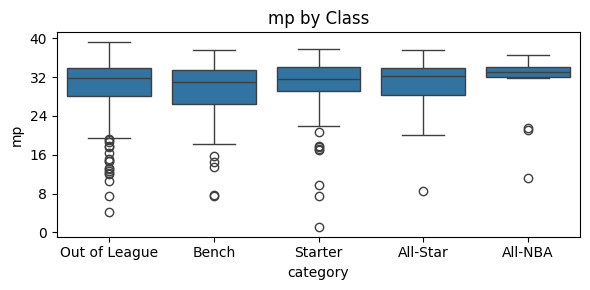

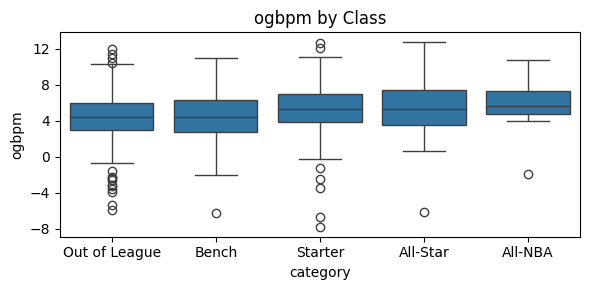

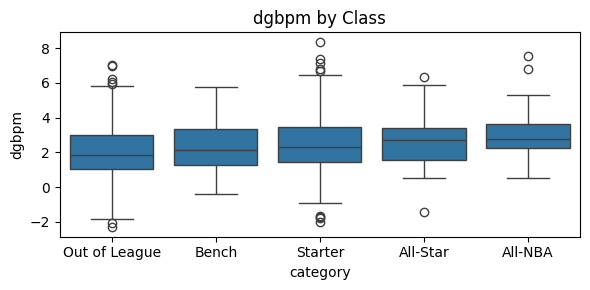

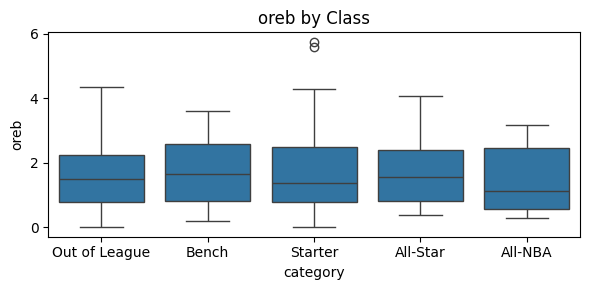

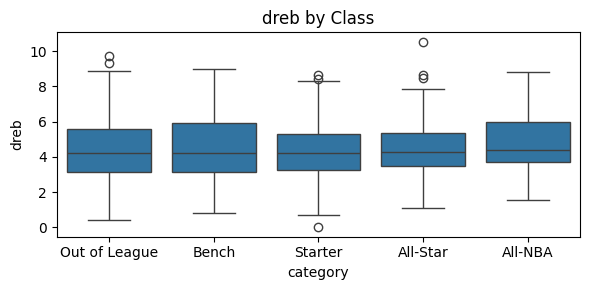

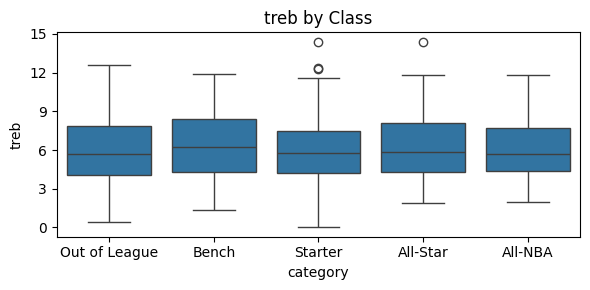

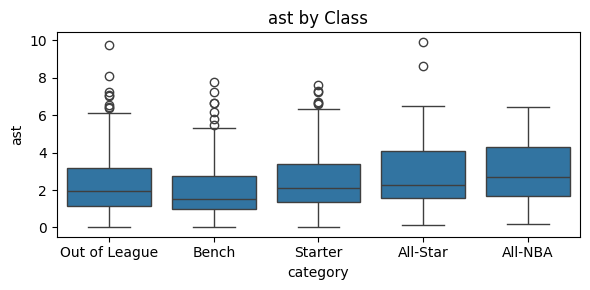

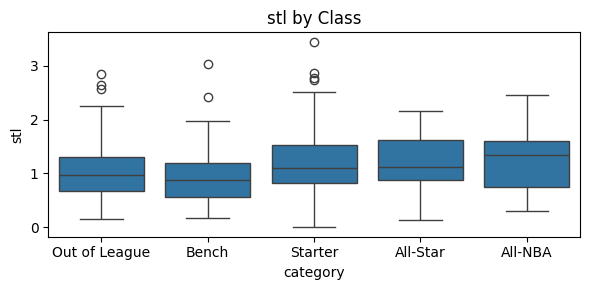

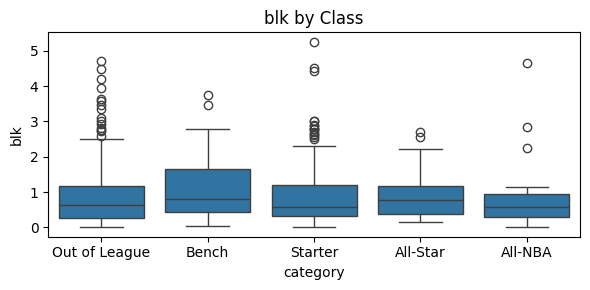

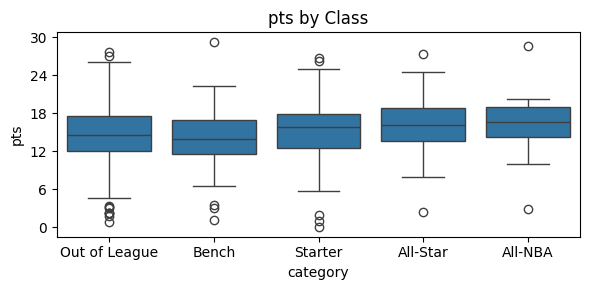

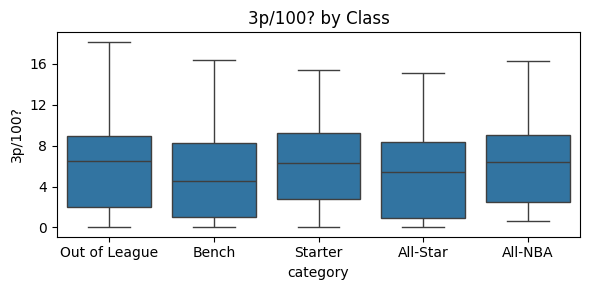

In [156]:
# Define the desired order for the categories
category_order = ['Out of League', 'Bench', 'Starter', 'All-Star', 'All-NBA']
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(
        x='category',
        y=col,
        data=df_main.assign(**{col: pd.to_numeric(df_main[col], errors='coerce')}),
        order=category_order
    )
    plt.title(f"{col} by Class")
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, integer=True))
    plt.tight_layout()
    plt.show()


### Building the Model

#### Step 1: Prepare features and target

In [182]:
# isolate features and target variable
if 'pick' in numeric_cols:
    numeric_cols.remove('pick') # now's the time to drop 'pick' as it is not a feature
X = df_main[numeric_cols]
y = df_main['category']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#### Step 2: Train/test split

In [183]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

#### Step 3: Define Preprocessing

In [205]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols)
])

#### Step 4: Defining potential models for GridSearch

In [206]:
models = {
    'logreg': LogisticRegression(max_iter=1000),
    'rf': RandomForestClassifier(),
    'svc': SVC(),
    'gb': GradientBoostingClassifier()
}

#### Step 5: Define the parameter grid

In [207]:
param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000, class_weight='balanced')],
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    {
        'classifier': [RandomForestClassifier(class_weight='balanced')],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20]
    },
    {
        'classifier': [SVC(class_weight='balanced')],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'classifier': [GradientBoostingClassifier()],
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 5]
    }
]

#### Step 6: Full pipeline with placeholder classifier

In [209]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression())  # default, will be overridden in param_grid
])

#### Step 7: Grid search over pipeline

In [210]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value=0,
                                                                                                        strategy='constant')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['GP',
                                                                          'Min_per',
                                                                          'ORtg',
                                                                          'usg',
                                                                          'eFG',
                                                                          'TS_per',
                                                                          'ORB_per',
                                                                          'DRB_per',
                                                                          'AST_per',
                                                                          'TO_per',
                                                                          'FTM',
                                                                          'FTA',
                                                                          'FT_per',
                                                                          'twoPM',
                                                                          'twoPA',
                                                                          'twoP_per',
                                                                          'TPM',
                                                                          'TPA',
                                                                          'T...
                          'classifier__max_depth': [None, 10, 20],
                          'classifier__n_estimators': [100, 200]},
                         {'classifier': [SVC(class_weight='balanced')],
                          'classifier__C': [0.1, 1, 10],
                          'classifier__kernel': ['linear', 'rbf']},
                         {'classifier': [GradientBoostingClassifier()],
                          'classifier__learning_rate': [0.05, 0.1],
                          'classifier__max_depth': [3, 5],
                          'classifier__n_estimators': [100, 200]}],
             scoring='accuracy')

#### Step 8: Evaluate

In [211]:
y_pred = grid_search.predict(X_test)
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

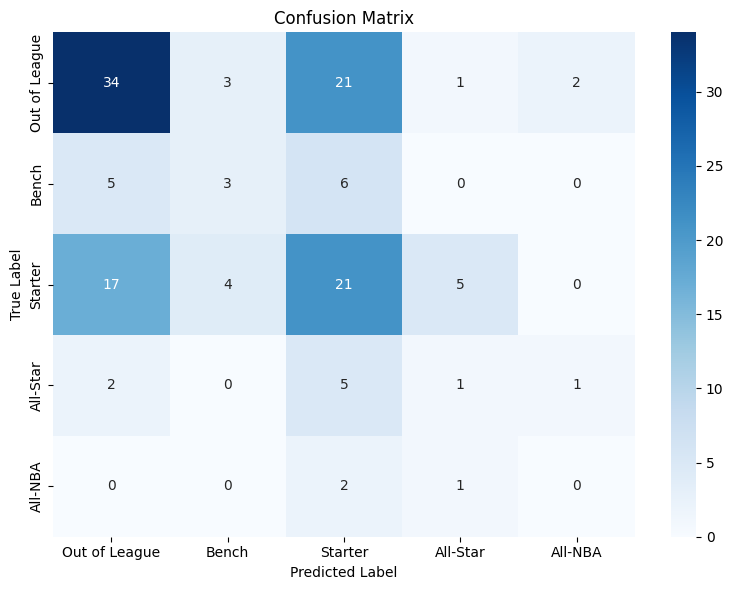

In [213]:
# Use the confusion matrix and report from previous cells if available
try:
    cm = conf_matrix
    # Ensure label order: Out of League, Bench, Starter, All-Star, All-NBA
    desired_order = ['Out of League', 'Bench', 'Starter', 'All-Star', 'All-NBA']
    # Map report keys to indices in the confusion matrix
    label_indices = [list(report.keys()).index(lbl) for lbl in desired_order if lbl in report]
    cm = cm[label_indices, :][:, label_indices]
    labels = desired_order
except:
    # Fallback if variables are not available
    cm = confusion_matrix(y_test, y_pred)
    labels = le.classes_
    # Reorder if possible
    desired_order = ['Out of League', 'Bench', 'Starter', 'All-Star', 'All-NBA']
    if set(desired_order) == set(labels):
        idx = [list(labels).index(lbl) for lbl in desired_order]
        cm = cm[idx, :][:, idx]
        labels = desired_order

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [214]:
grid_search.best_params_, grid_search.best_score_

({'classifier': RandomForestClassifier(class_weight='balanced'),
  'classifier__max_depth': None,
  'classifier__n_estimators': 200},
 np.float64(0.4323752424616469))

### Predictions for this year

In [222]:
df_now

,player_name,team,conf,GP,Min_per,ORtg,usg,eFG,TS_per,ORB_per,...,blk,pts,role,3p/100?,PLAYER_NAME,all_star,starter,bench,all_nba,category
85787,Mike Saunders Jr.,Pepperdine,WCC,17,9.1,89.4,11.2,33.3,44.89,0.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Out of League
82147,Jordan Williams,Arizona St.,B12,7,0.4,200.0,5.8,100.0,100.0,0.0,...,0.0,0.2857,PF/C,0.0,Jordan Williams,0.0,0.0,0.0,0.0,Out of League
83012,Wesley Johnson,Campbell,CAA,4,0.8,93.4,31.1,41.7,41.67,12.8,...,0.0,1.1667,PF/C,25.1723,Wesley Johnson,0.0,1.0,1.0,0.0,Starter
82767,Jordan Crawford,Eastern Kentucky,ASun,28,52.5,106.1,16.4,47.2,49.82,3.0,...,0.0667,7.8,Combo G,12.0177,Jordan Crawford,0.0,1.0,1.0,0.0,Starter
80861,Nick Johnson,Winthrop,BSth,31,69.9,104.8,22.4,49.8,54.92,3.6,...,0.4706,12.5882,Combo G,7.79937,Nick Johnson,0.0,0.0,0.0,0.0,Out of League
84588,Brandon Jennings,VCU,A10,34,32.2,108.0,13.6,42.7,47.04,7.7,...,0.3429,2.6857,Wing G,3.56799,Brandon Jennings,0.0,1.0,1.0,0.0,Starter
85579,Jordan Hamilton,SIU Edwardsville,OVC,6,0.8,0.0,17.6,0.0,0.0,0.0,...,0.0,1.6667,PF/C,11.8725,Jordan Hamilton,0.0,0.0,1.0,0.0,Bench
85270,Isaiah Jackson,Drake,MVC,32,47.4,98.2,16.1,44.3,48.17,5.8,...,0.0588,3.8235,Wing G,3.23835,Isaiah Jackson,0.0,0.0,0.0,0.0,Out of League
